In [76]:
import time
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn import preprocessing
import joblib

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce GTX 1660 Ti


In [77]:
# ── Data ─────────────────────────────────────────────────────────────────────
DATA_PATH = 'suspension_dataset.mat'   # update path if needed
N_SAMPLES = None  # samples per signal pair; set None for full 100k (GPU recommended)
SEQ_LEN   = 1000       # road history window [samples] = 500 ms at 1 kHz
STRIDE    = 5        # step between windows (reduces dataset size)

# ── Model ────────────────────────────────────────────────────────────────────
HIDDEN_DIM  = 128      # GRU hidden state size
FC_WIDTH    = 200     # width of each fully-connected layer in the MLP decoder
# MAX_BODY_TRAVEL and MAX_TYRE_TRAVEL are computed from the data after loading
MAX_BODY_TRAVEL = None
MAX_TYRE_TRAVEL = None
LAMBDA_PHYS = 0.5  # weight for physics loss term (0 = no physics loss, 1 = equal weight to MSE loss)

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE   = 128
EPOCHS       = 300
LR_PATIENCE  = 10     # epochs before ReduceLROnPlateau reduces LR
LR_FACTOR    = 0.9
LR_MIN       = 1e-16
MAX_PATIENCE = 50     # early stopping patience
LOG_EVERY    = 5      # print batch progress every N batches

Ts = 0.001            # sampling interval [s]
N  = 100_000          # full period length in the .mat file

print('Configuration set.')
print(f'  N_SAMPLES = {N_SAMPLES}  (None = full 100k)')
print(f'  SEQ_LEN   = {SEQ_LEN} samples ({SEQ_LEN * Ts * 1000:.0f} ms of road history)')

Configuration set.
  N_SAMPLES = None  (None = full 100k)
  SEQ_LEN   = 1000 samples (1000 ms of road history)


Signal pairs loaded : 15  (expected 15)
Samples per pair    : 100,000


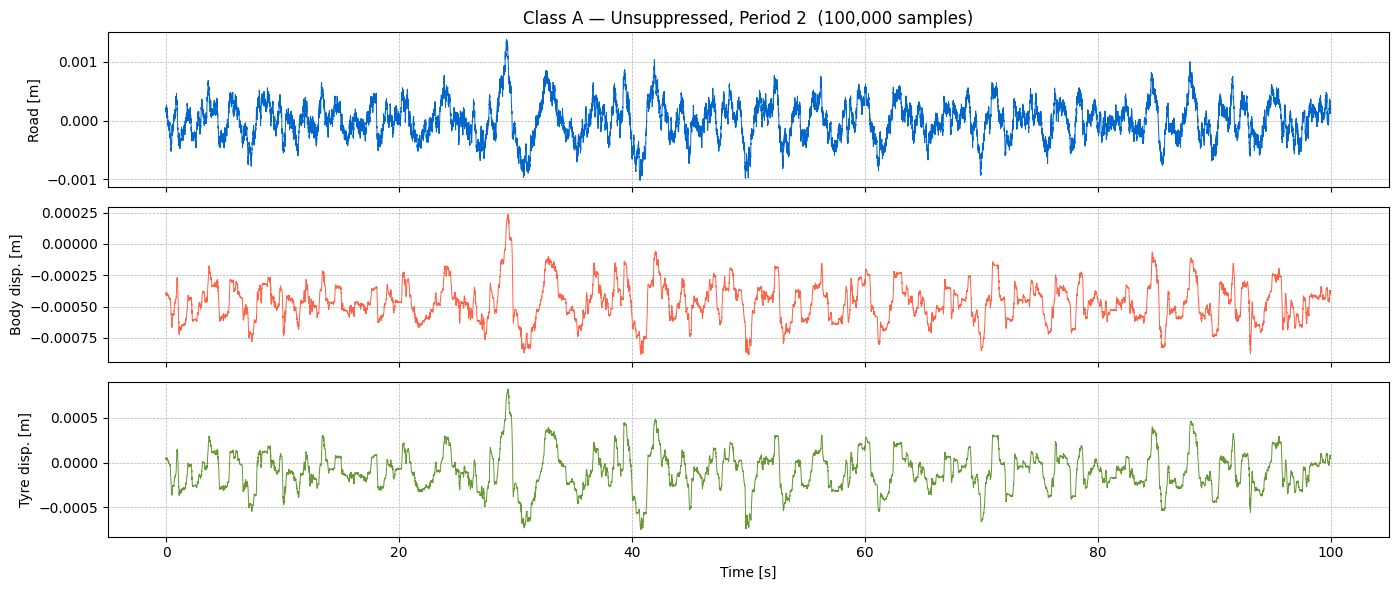

In [78]:
raw     = sio.loadmat(DATA_PATH)
CLASSES = ['A', 'B', 'C', 'D', 'E']
cap     = N_SAMPLES if N_SAMPLES is not None else N

road_signals, body_signals, tyre_signals = [], [], []

for cls in CLASSES:
    road_x = raw[f'hx{cls}'].flatten()
    body_x = raw[f'bodyxsuppressed{cls}'].flatten()
    tyre_x = raw[f'tirexsuppressed{cls}'].flatten()

    # Periods 2, 3, 4 — skip period 1 (transient)
    for p in range(1, 4):
        sl = slice(p * N, p * N + cap)
        road_signals.append(road_x[:cap])
        body_signals.append(body_x[sl])
        tyre_signals.append(tyre_x[sl])

print(f'Signal pairs loaded : {len(road_signals)}  (expected 15)')
print(f'Samples per pair    : {road_signals[0].shape[0]:,}')

# ── Sanity plot ───────────────────────────────────────────────────────────────
t_ax = np.arange(cap) * Ts
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
for ax, sig, lbl, col in zip(
    axes,
    [road_signals[0], body_signals[0], tyre_signals[0]],
    ['Road [m]', 'Body disp. [m]', 'Tyre disp. [m]'],
    ['#0066cc', 'tomato', '#669933']
):
    ax.plot(t_ax, sig, lw=0.7, color=col)
    ax.set_ylabel(lbl)
    ax.grid(True, linestyle='--', linewidth=0.5)
axes[0].set_title(f'Class A — Unsuppressed, Period 2  ({cap:,} samples)')
axes[2].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

In [79]:
# ── Compute global z-score statistics ─────────────────────────────────────────
all_road = np.concatenate(road_signals)
all_body = np.concatenate(body_signals)
all_tyre = np.concatenate(tyre_signals)

road_mean, road_std = float(all_road.mean()), float(all_road.std())
body_mean, body_std = float(all_body.mean()), float(all_body.std())
tyre_mean, tyre_std = float(all_tyre.mean()), float(all_tyre.std())

# Save for inference
scaler_stats = {
    'road_mean': road_mean, 'road_std': road_std,
    'body_mean': body_mean, 'body_std': body_std,
    'tyre_mean': tyre_mean, 'tyre_std': tyre_std,
}
joblib.dump(scaler_stats, 'zscore_stats.pkl')
print('Z-score stats saved to zscore_stats.pkl')

print(f'Road  mean={road_mean:+.6f} m   std={road_std:.6f} m')
print(f'Body  mean={body_mean:+.6f} m   std={body_std:.6f} m')
print(f'Tyre  mean={tyre_mean:+.6f} m   std={tyre_std:.6f} m')

# ── Normalise ─────────────────────────────────────────────────────────────────
road_norm = [(s - road_mean) / road_std for s in road_signals]
body_norm = [(s - body_mean) / body_std for s in body_signals]
tyre_norm = [(s - tyre_mean) / tyre_std for s in tyre_signals]

print(f'\nRoad scaled range: [{np.concatenate(road_norm).min():.3f}, {np.concatenate(road_norm).max():.3f}]')
print(f'Body scaled range: [{np.concatenate(body_norm).min():.3f}, {np.concatenate(body_norm).max():.3f}]')
print(f'Tyre scaled range: [{np.concatenate(tyre_norm).min():.3f}, {np.concatenate(tyre_norm).max():.3f}]')

Z-score stats saved to zscore_stats.pkl
Road  mean=+0.000000 m   std=0.001813 m
Body  mean=-0.000453 m   std=0.001817 m
Tyre  mean=-0.000104 m   std=0.001774 m

Road scaled range: [-5.999, 8.161]
Body scaled range: [-8.703, 7.357]
Tyre scaled range: [-9.208, 8.032]


In [80]:
# -------------------------
# Define GRU-based Neural Network
# -------------------------
class SuspensionGRU(nn.Module):
    def __init__(self, input_size, output_size, hidden_size=32, fc_width=100):
        """
        A deep GRU model with two stacked GRU layers followed by three fully connected (dense) layers.
        Used to predict the current stress state given a time history of strain tensors.

        Parameters:
            input_size (int): Number of features in the input (e.g., 6 strain components).
            output_size (int): Number of outputs to predict (e.g., 6 stress components).
            hidden_size (int): Dimensionality of the hidden state in each GRU layer.
            fc_width (int): Number of units in each dense layer.
        """
        super().__init__()

        # First GRU layer
        self.gru1 = nn.GRU(input_size, hidden_size, batch_first=True)

        # Second GRU layer
        self.gru2 = nn.GRU(hidden_size, hidden_size, batch_first=True)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size, fc_width)
        self.fc2 = nn.Linear(fc_width, fc_width)
        self.fc3 = nn.Linear(fc_width, fc_width)

        # Output layer
        self.fc4 = nn.Linear(fc_width, output_size)

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        """
        Forward pass through the network.

        Parameters:
            x (tensor): Input tensor of shape (batch_size, sequence_length, input_size)

        Returns:
            tensor: Predicted output of shape (batch_size, output_size)
        """
        # First GRU layer: processes the input sequence and returns outputs at all timesteps
        # We discard the second output (hidden state) because we manually extract the last timestep later
        x, _ = self.gru1(x)
        x = self.relu(x)  # Apply non-linearity after the first GRU

        # Second GRU layer: takes the sequence from the first GRU and further refines it
        x, _ = self.gru2(x)
        x = self.relu(x)  # Another ReLU activation for stability and expressiveness

        # Select the output from the final timestep only (many-to-one setup)
        # Shape changes from (batch_size, seq_len, hidden_size) → (batch_size, hidden_size)
        x = x[:, -1, :]

        # Fully connected layers (MLP): map the final GRU output to the stress prediction
        x = self.relu(self.fc1(x))  # First dense layer with ReLU
        x = self.relu(self.fc2(x))  # Second dense layer with ReLU (Residual connection)
        x = self.relu(self.fc3(x))  # Third dense layer with ReLU (Residual connection)

        # Final output layer (no activation): maps to 6 stress components
        return self.fc4(x)


model = SuspensionGRU(
    input_size  = 1,
    output_size = 2,
    hidden_size = HIDDEN_DIM,
    fc_width    = FC_WIDTH
).to(device)

In [81]:
# ═══════════════════════════════════════════════════════════════════════════════
# Evaluate on a single road class (continuous, unshuffled, unsuppressed only)
# ═══════════════════════════════════════════════════════════════════════════════

# ── Choose signal ─────────────────────────────────────────────────────────────
ROAD_CLASS = 'E'      # 'A', 'B', 'C', 'D', 'E'

# ── Load raw signal pair (unsuppressed, period 2 only) ────────────────────────
road_raw = raw[f'hx{ROAD_CLASS}'].flatten()[:cap]
body_raw = raw[f'bodyxsuppressed{ROAD_CLASS}'].flatten()[N : N + cap]
tyre_raw = raw[f'tirexsuppressed{ROAD_CLASS}'].flatten()[N : N + cap]

# ── Scale ─────────────────────────────────────────────────────────────────────
road_sc = (road_raw - road_mean) / road_std

# ── Build continuous windows (stride=1, no shuffle) ───────────────────────────
windows = np.lib.stride_tricks.sliding_window_view(road_sc, SEQ_LEN)
n = min(len(windows), len(body_raw) - SEQ_LEN + 1)

X_inf = torch.tensor(windows[:n], dtype=torch.float32).unsqueeze(-1).to(device)

# ── Inference in batches ──────────────────────────────────────────────────────
#model.load_state_dict(torch.load('gru_zscore_h128_fc200_seq1000_s5_100k.pt', map_location=device))
model.load_state_dict(torch.load('best_suspension_gru.pt', map_location=device))

model.eval()

preds_list = []
with torch.no_grad():
    for i in range(0, n, BATCH_SIZE):
        preds_list.append(model(X_inf[i:i+BATCH_SIZE]).cpu().numpy())

preds_sc = np.concatenate(preds_list, axis=0)

# ── Inverse-transform to metres ──────────────────────────────────────────────
preds_body = preds_sc[:, 0] * body_std + body_mean
preds_tyre = preds_sc[:, 1] * tyre_std + tyre_mean
targets_body = body_raw[SEQ_LEN - 1 : SEQ_LEN - 1 + n]
targets_tyre = tyre_raw[SEQ_LEN - 1 : SEQ_LEN - 1 + n]

# ── Metrics ───────────────────────────────────────────────────────────────────
title = f'Class {ROAD_CLASS} — Unsuppressed — Period 2'

def report(pred, true, label):
    rmse = np.sqrt(np.mean((pred - true) ** 2))
    mae  = np.mean(np.abs(pred - true))
    print(f'  {label:6s}  RMSE: {rmse*1000:.4f} mm   MAE: {mae*1000:.4f} mm')

print(f'{title}')
print(f'Samples: {n:,}\n')
report(preds_body, targets_body, 'Body')
report(preds_tyre, targets_tyre, 'Tyre')

Class E — Unsuppressed — Period 2
Samples: 99,001

  Body    RMSE: 0.0801 mm   MAE: 0.0621 mm
  Tyre    RMSE: 0.0956 mm   MAE: 0.0752 mm


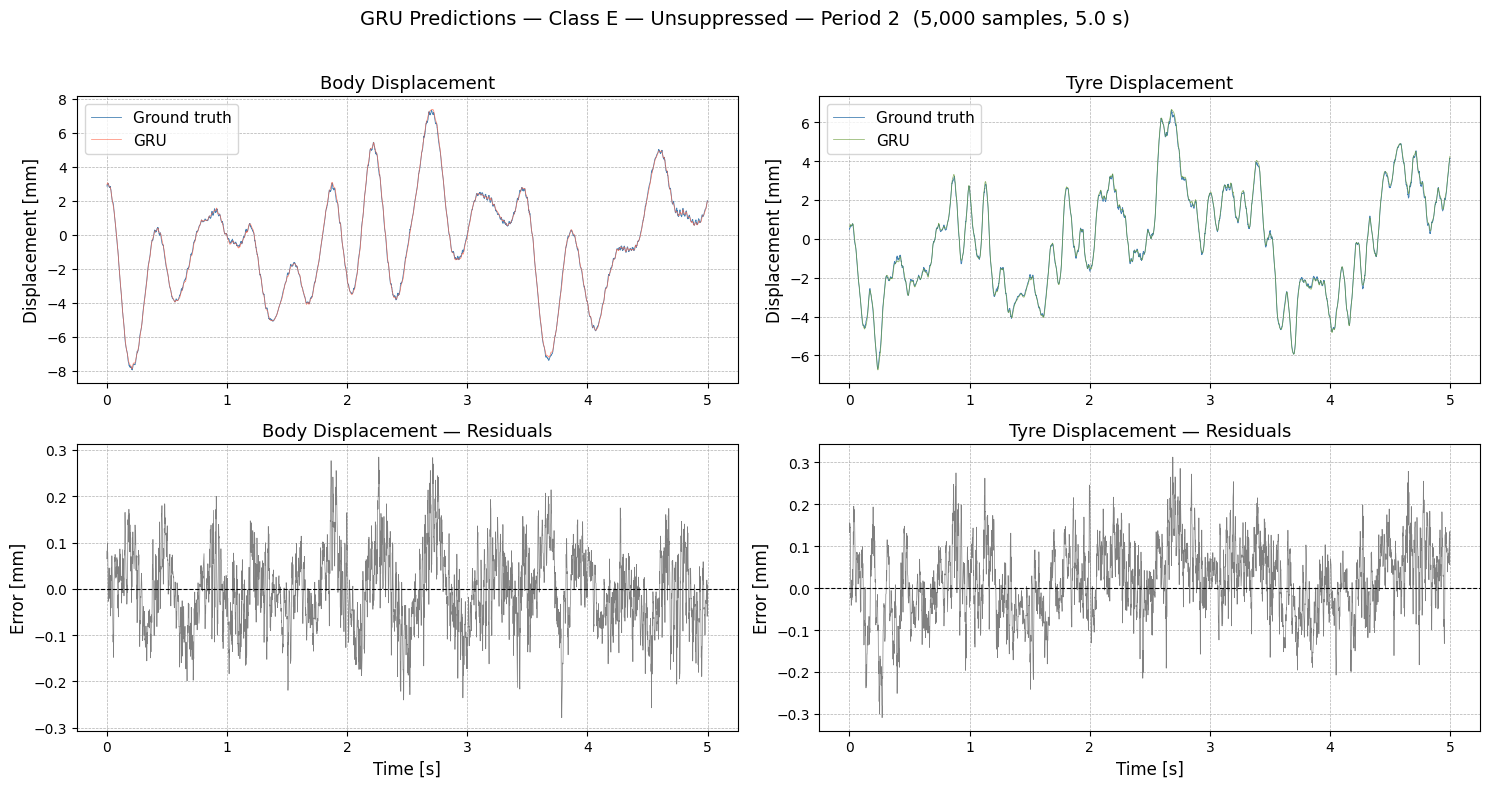

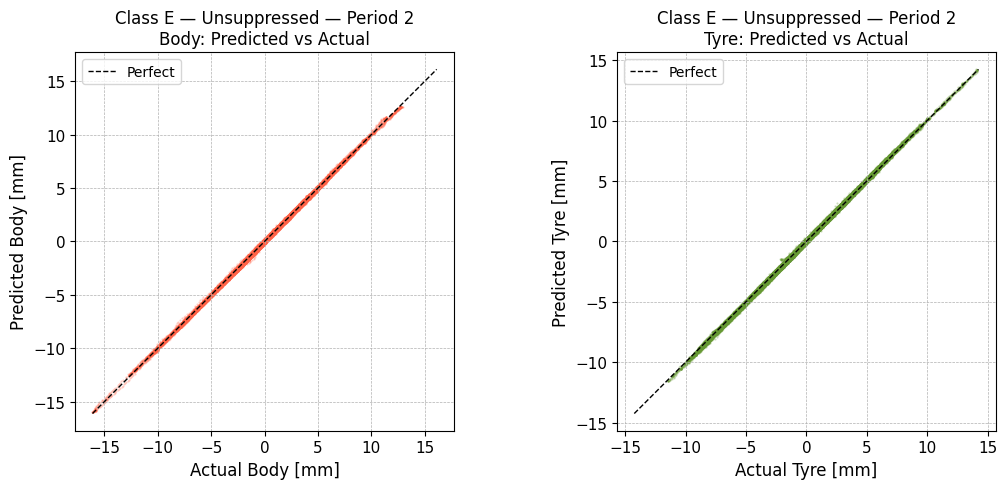

In [82]:
# ═══════════════════════════════════════════════════════════════════════════════
# Plot continuous predictions for the selected road class
# ═══════════════════════════════════════════════════════════════════════════════

PLOT_SAMPLES = 5000     # how many samples to display (set None for all)
# Try: 5000, 10000, 20000, 50000, None

p = PLOT_SAMPLES if PLOT_SAMPLES is not None else n
p = min(p, n)   # don't exceed available predictions

t_plot = np.arange(p) * Ts

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

plot_cfg = [
    (axes[0, 0], axes[1, 0], targets_body[:p], preds_body[:p], 'Body Displacement', 'tomato'),
    (axes[0, 1], axes[1, 1], targets_tyre[:p], preds_tyre[:p], 'Tyre Displacement', '#669933'),
]
for ax_top, ax_bot, truth, pred, label, col in plot_cfg:
    ax_top.plot(t_plot, truth*1000, lw=0.6, color='steelblue', label='Ground truth')
    ax_top.plot(t_plot, pred*1000,  lw=0.5, color=col, alpha=0.8, label='GRU')
    ax_top.set_title(label, fontsize=13)
    ax_top.set_ylabel('Displacement [mm]', fontsize=12)
    ax_top.legend(fontsize=11)
    ax_top.grid(True, linestyle='--', linewidth=0.5)

    residual = (pred - truth) * 1000
    ax_bot.plot(t_plot, residual, lw=0.5, color='grey')
    ax_bot.axhline(0, color='k', lw=0.8, ls='--')
    ax_bot.set_title(f'{label} — Residuals', fontsize=13)
    ax_bot.set_ylabel('Error [mm]', fontsize=12)
    ax_bot.set_xlabel('Time [s]', fontsize=12)
    ax_bot.grid(True, linestyle='--', linewidth=0.5)

plt.suptitle(f'GRU Predictions — {title}  ({p:,} samples, {p*Ts:.1f} s)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ── Scatter (always uses ALL predictions for accurate metrics) ────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
for ax, pred, truth, label, col in [
    (ax1, preds_body, targets_body, 'Body', 'tomato'),
    (ax2, preds_tyre, targets_tyre, 'Tyre', '#669933')
]:
    ax.scatter(truth*1000, pred*1000, s=0.3, alpha=0.3, color=col)
    lim = max(np.abs(truth).max(), np.abs(pred).max()) * 1000
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1, label='Perfect')
    ax.set_xlabel(f'Actual {label} [mm]', fontsize=12)
    ax.set_ylabel(f'Predicted {label} [mm]', fontsize=12)
    ax.set_title(f'{title}\n{label}: Predicted vs Actual', fontsize=12)
    ax.set_aspect('equal')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

In [83]:
# ═══════════════════════════════════════════════════════════════════════════════
# Per-Class Metrics Summary
# ═══════════════════════════════════════════════════════════════════════════════

def metrics(pred, true, name):
    rmse = np.sqrt(np.mean((pred - true)**2))
    mae = np.mean(np.abs(pred - true))
    nrmse_range = rmse / (true.max() - true.min())
    nrmse_std = rmse / np.std(true)
    corr = np.corrcoef(pred, true)[0, 1]
    return {
        'rmse': rmse * 1000,
        'mae': mae * 1000,
        'nrmse_range': nrmse_range * 100,
        'nrmse_std': nrmse_std * 100,
        'corr': corr
    }

class_results = {}

for cls in ['A', 'B', 'C', 'D', 'E']:
    road_raw = raw[f'hx{cls}'].flatten()[:cap]
    body_raw = raw[f'bodyxsuppressed{cls}'].flatten()[N : N + cap]
    tyre_raw = raw[f'tirexsuppressed{cls}'].flatten()[N : N + cap]

    road_sc = (road_raw - road_mean) / road_std
    windows = np.lib.stride_tricks.sliding_window_view(road_sc, SEQ_LEN)
    n = min(len(windows), len(body_raw) - SEQ_LEN + 1)
    X_inf = torch.tensor(windows[:n], dtype=torch.float32).unsqueeze(-1).to(device)

    preds_list = []
    with torch.no_grad():
        for i in range(0, n, BATCH_SIZE):
            preds_list.append(model(X_inf[i:i+BATCH_SIZE]).cpu().numpy())
    preds_sc = np.concatenate(preds_list, axis=0)

    pb = preds_sc[:, 0] * body_std + body_mean
    pt = preds_sc[:, 1] * tyre_std + tyre_mean
    tb = body_raw[SEQ_LEN - 1 : SEQ_LEN - 1 + n]
    tt = tyre_raw[SEQ_LEN - 1 : SEQ_LEN - 1 + n]

    class_results[cls] = {
        'body': metrics(pb, tb, f'Class {cls} Body'),
        'tyre': metrics(pt, tt, f'Class {cls} Tyre')
    }

# ── Print summary table ──────────────────────────────────────────────────────
print('\n' + '=' * 100)
print('BODY DISPLACEMENT')
print(f'{"Class":<8} {"RMSE [mm]":<12} {"MAE [mm]":<12} {"NRMSE/range":<14} {"NRMSE/std":<14} {"Correlation":<12}')
print('-' * 100)
for cls in ['A', 'B', 'C', 'D', 'E']:
    b = class_results[cls]['body']
    print(f'{cls:<8} {b["rmse"]:<12.4f} {b["mae"]:<12.4f} {b["nrmse_range"]:<12.2f}% {b["nrmse_std"]:<12.2f}% {b["corr"]:<12.4f}')

print('\nTYRE DISPLACEMENT')
print(f'{"Class":<8} {"RMSE [mm]":<12} {"MAE [mm]":<12} {"NRMSE/range":<14} {"NRMSE/std":<14} {"Correlation":<12}')
print('-' * 100)
for cls in ['A', 'B', 'C', 'D', 'E']:
    t = class_results[cls]['tyre']
    print(f'{cls:<8} {t["rmse"]:<12.4f} {t["mae"]:<12.4f} {t["nrmse_range"]:<12.2f}% {t["nrmse_std"]:<12.2f}% {t["corr"]:<12.4f}')


BODY DISPLACEMENT
Class    RMSE [mm]    MAE [mm]     NRMSE/range    NRMSE/std      Correlation 
----------------------------------------------------------------------------------------------------
A        0.0266       0.0231       2.36        % 17.35       % 0.9953      
B        0.0306       0.0263       1.15        % 8.03        % 0.9990      
C        0.0330       0.0266       0.60        % 4.39        % 0.9994      
D        0.0551       0.0439       0.42        % 3.24        % 0.9996      
E        0.0801       0.0621       0.28        % 2.25        % 0.9997      

TYRE DISPLACEMENT
Class    RMSE [mm]    MAE [mm]     NRMSE/range    NRMSE/std      Correlation 
----------------------------------------------------------------------------------------------------
A        0.0196       0.0156       1.24        % 9.09        % 0.9977      
B        0.0251       0.0201       0.73        % 5.30        % 0.9993      
C        0.0353       0.0282       0.55        % 4.07        % 0.9995   

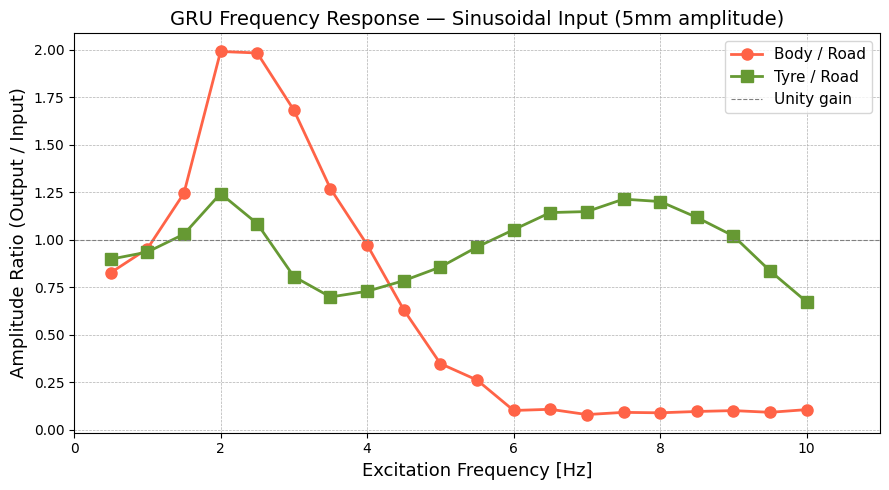

In [84]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3. Frequency Response Analysis (Bode-like plot)
#    Sweep sine waves at different frequencies and measure amplitude ratio
# ═══════════════════════════════════════════════════════════════════════════════

test_freqs = np.linspace(0.5, 10.0, 20)
amplitude  = 0.005   # 5mm sine input — within training range

body_gains = []
tyre_gains = []

for freq in test_freqs:
    t_test = np.arange(10000) * Ts
    road_sine = amplitude * np.sin(2 * np.pi * freq * t_test)

    road_sc = (road_sine - road_mean) / road_std
    windows = np.lib.stride_tricks.sliding_window_view(road_sc, SEQ_LEN)
    n = len(windows)
    X_inf = torch.tensor(windows[:n], dtype=torch.float32).unsqueeze(-1).to(device)

    preds_list = []
    with torch.no_grad():
        for i in range(0, n, BATCH_SIZE):
            preds_list.append(model(X_inf[i:i+BATCH_SIZE]).cpu().numpy())
    preds_sc = np.concatenate(preds_list, axis=0)

    pb = preds_sc[:, 0] * body_std + body_mean
    pt = preds_sc[:, 1] * tyre_std + tyre_mean

    # Use last 5 seconds (steady state) to measure amplitude
    steady = int(5.0 / Ts)
    body_amp = (np.max(pb[steady:]) - np.min(pb[steady:])) / 2
    tyre_amp = (np.max(pt[steady:]) - np.min(pt[steady:])) / 2

    body_gains.append(body_amp / amplitude)
    tyre_gains.append(tyre_amp / amplitude)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(test_freqs, body_gains, 'o-', color='tomato', lw=2, markersize=8, label='Body / Road')
ax.plot(test_freqs, tyre_gains, 's-', color='#669933', lw=2, markersize=8, label='Tyre / Road')
ax.axhline(1.0, color='grey', ls='--', lw=0.8, label='Unity gain')
ax.set_xlabel('Excitation Frequency [Hz]', fontsize=13)
ax.set_ylabel('Amplitude Ratio (Output / Input)', fontsize=13)
ax.set_title('GRU Frequency Response — Sinusoidal Input (5mm amplitude)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', linewidth=0.5)
ax.set_xlim([0, 11])
plt.tight_layout()
plt.show()

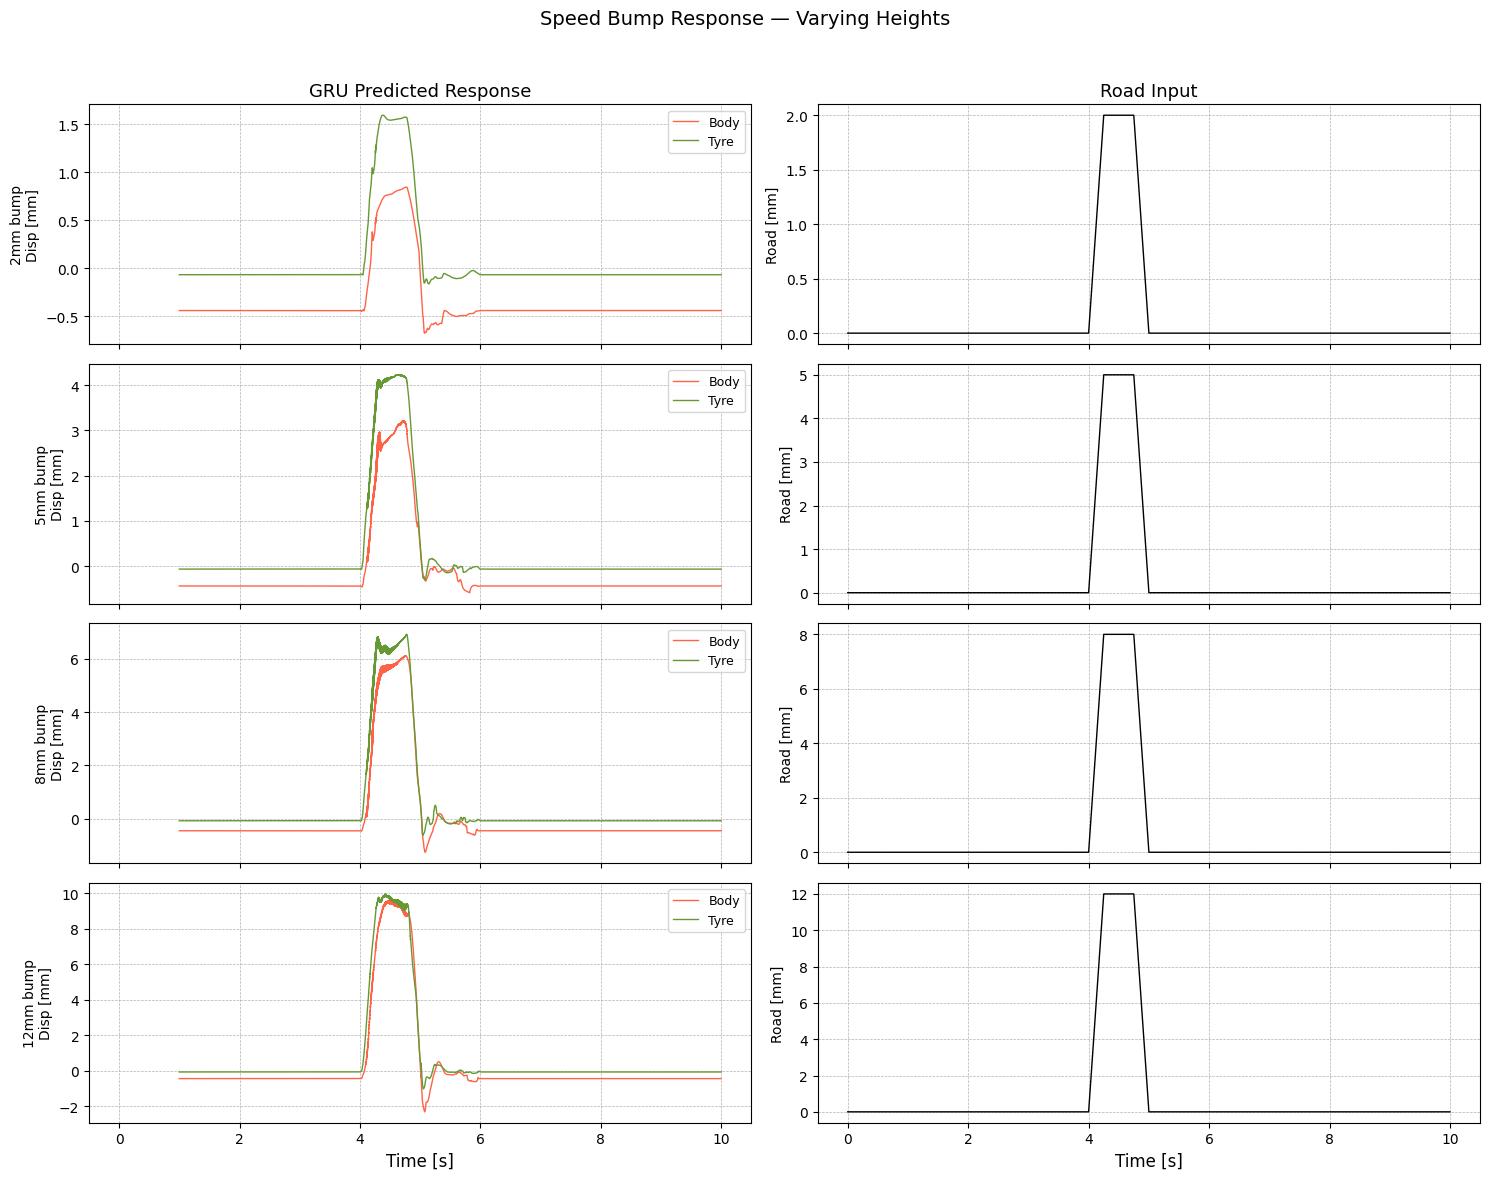

In [85]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4. Speed Bump Test — Varying Heights
# ═══════════════════════════════════════════════════════════════════════════════

def speed_bump(t, start, width, height):
    road = np.zeros_like(t)
    ramp = width * 0.25
    flat = width * 0.5
    t1, t2, t3, t4 = start, start + ramp, start + ramp + flat, start + width
    road[(t >= t1) & (t < t2)] = height * ((t[(t >= t1) & (t < t2)] - t1) / ramp)
    road[(t >= t2) & (t < t3)] = height
    road[(t >= t3) & (t < t4)] = height * (1 - (t[(t >= t3) & (t < t4)] - t3) / ramp)
    return road

bump_heights = [0.002, 0.005, 0.008, 0.012]   # 2mm, 5mm, 8mm, 12mm
t_test = np.arange(10000) * Ts

fig, axes = plt.subplots(len(bump_heights), 2, figsize=(15, 3 * len(bump_heights)), sharex=True)

for row, h in enumerate(bump_heights):
    road = speed_bump(t_test, start=4.0, width=1.0, height=h)
    road_sc = (road - road_mean) / road_std
    windows = np.lib.stride_tricks.sliding_window_view(road_sc, SEQ_LEN)
    n = len(windows)
    X_inf = torch.tensor(windows[:n], dtype=torch.float32).unsqueeze(-1).to(device)

    preds_list = []
    with torch.no_grad():
        for i in range(0, n, BATCH_SIZE):
            preds_list.append(model(X_inf[i:i+BATCH_SIZE]).cpu().numpy())
    preds_sc = np.concatenate(preds_list, axis=0)

    pb = preds_sc[:, 0] * body_std + body_mean
    pt = preds_sc[:, 1] * tyre_std + tyre_mean
    t_pred = t_test[SEQ_LEN - 1 : SEQ_LEN - 1 + n]

    axes[row, 0].plot(t_pred, pb * 1000, color='tomato', lw=1.0, label='Body')
    axes[row, 0].plot(t_pred, pt * 1000, color='#669933', lw=1.0, label='Tyre')
    axes[row, 0].set_ylabel(f'{h*1000:.0f}mm bump\nDisp [mm]', fontsize=10)
    axes[row, 0].legend(fontsize=9)
    axes[row, 0].grid(True, linestyle='--', linewidth=0.5)

    axes[row, 1].plot(t_test, road * 1000, 'k', lw=1.0)
    axes[row, 1].set_ylabel('Road [mm]', fontsize=10)
    axes[row, 1].grid(True, linestyle='--', linewidth=0.5)

axes[0, 0].set_title('GRU Predicted Response', fontsize=13)
axes[0, 1].set_title('Road Input', fontsize=13)
axes[-1, 0].set_xlabel('Time [s]', fontsize=12)
axes[-1, 1].set_xlabel('Time [s]', fontsize=12)
plt.suptitle('Speed Bump Response — Varying Heights', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

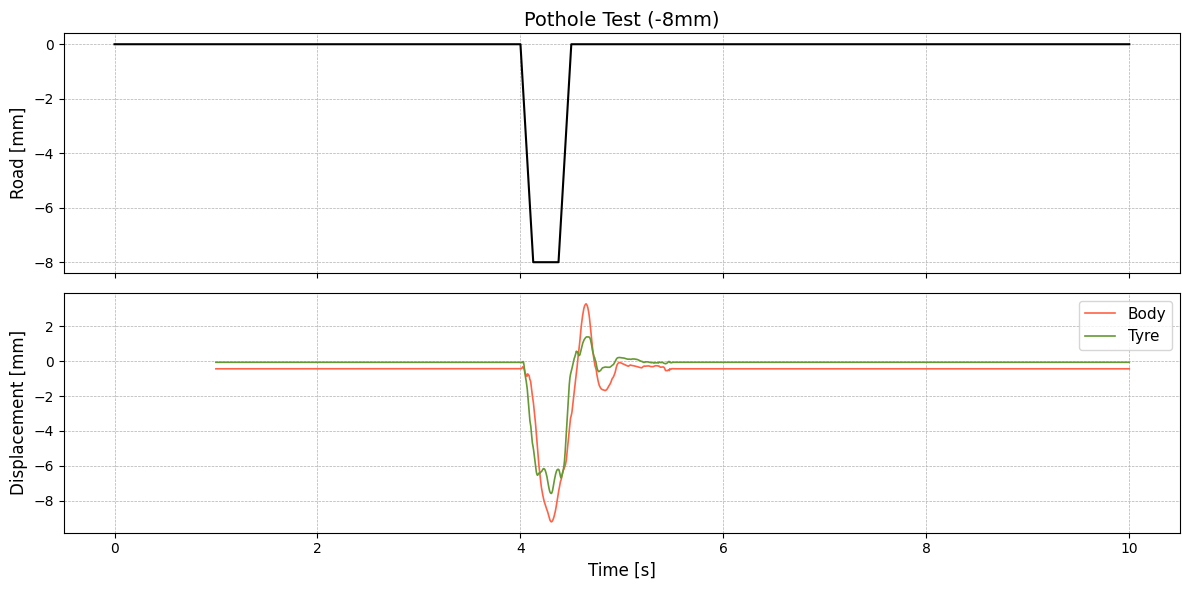

In [86]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5. Pothole Test (negative bump)
# ═══════════════════════════════════════════════════════════════════════════════

road_pothole = speed_bump(t_test, start=4.0, width=0.5, height=-0.008)  # -8mm pothole

road_sc = (road_pothole - road_mean) / road_std
windows = np.lib.stride_tricks.sliding_window_view(road_sc, SEQ_LEN)
n = len(windows)
X_inf = torch.tensor(windows[:n], dtype=torch.float32).unsqueeze(-1).to(device)

preds_list = []
with torch.no_grad():
    for i in range(0, n, BATCH_SIZE):
        preds_list.append(model(X_inf[i:i+BATCH_SIZE]).cpu().numpy())
preds_sc = np.concatenate(preds_list, axis=0)

pb = preds_sc[:, 0] * body_std + body_mean
pt = preds_sc[:, 1] * tyre_std + tyre_mean
t_pred = t_test[SEQ_LEN - 1 : SEQ_LEN - 1 + n]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t_test, road_pothole * 1000, 'k', lw=1.5)
axes[0].set_ylabel('Road [mm]', fontsize=12)
axes[0].set_title('Pothole Test (-8mm)', fontsize=14)
axes[0].grid(True, linestyle='--', linewidth=0.5)

axes[1].plot(t_pred, pb * 1000, color='tomato', lw=1.2, label='Body')
axes[1].plot(t_pred, pt * 1000, color='#669933', lw=1.2, label='Tyre')
axes[1].set_ylabel('Displacement [mm]', fontsize=12)
axes[1].set_xlabel('Time [s]', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [87]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6. Model Summary Table (for report)
# ═══════════════════════════════════════════════════════════════════════════════

print('=' * 60)
print('MODEL SUMMARY')
print('=' * 60)
print(f'Architecture:     2-layer GRU + 3-layer MLP decoder')
print(f'Hidden dim:       {HIDDEN_DIM}')
print(f'FC width:         {FC_WIDTH}')
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters:       {n_params:,}')
print(f'Sequence length:  {SEQ_LEN} ({SEQ_LEN * Ts * 1000:.0f} ms)')
print(f'Normalisation:    Z-score (global)')
print(f'Optimizer:        NAdam')
print(f'LR scheduler:     ReduceLROnPlateau (factor={LR_FACTOR}, patience={LR_PATIENCE})')
print(f'Training data:    5 ISO 8608 classes (A-E), unsuppressed, period 2')
print(f'Samples/class:    {cap:,}')
print(f'Stride:           {STRIDE}')
print()
print('PER-CLASS PERFORMANCE:')
print(f'{"Class":<8} {"Body RMSE [mm]":<16} {"Tyre RMSE [mm]":<16} {"Body r":<10} {"Tyre r":<10}')
print('-' * 60)
for cls in ['A', 'B', 'C', 'D', 'E']:
    r = class_results[cls]
    print(f'{cls:<8} {r["rmse_b"]:<16.4f} {r["rmse_t"]:<16.4f} {r["corr_b"]:<10.4f} {r["corr_t"]:<10.4f}')

MODEL SUMMARY
Architecture:     2-layer GRU + 3-layer MLP decoder
Hidden dim:       128
FC width:         200
Parameters:       255,978
Sequence length:  1000 (1000 ms)
Normalisation:    Z-score (global)
Optimizer:        NAdam
LR scheduler:     ReduceLROnPlateau (factor=0.9, patience=10)
Training data:    5 ISO 8608 classes (A-E), unsuppressed, period 2
Samples/class:    100,000
Stride:           5

PER-CLASS PERFORMANCE:
Class    Body RMSE [mm]   Tyre RMSE [mm]   Body r     Tyre r    
------------------------------------------------------------


KeyError: 'rmse_b'

In [ ]:
import scipy.io
import numpy as np

# 1. Load the datasets
# Ensure these files are in the same directory as your Python script
data = scipy.io.loadmat('suspension_dataset.mat')
hw_preds = scipy.io.loadmat('HW_Benchmark_Predictions.mat')

# ==========================================
# CLASS A EXAMPLE (Index 0 in MATLAB cells)
# ==========================================

# 2. Extract Road Profiles (The Inputs to your NN)
# Flatten is used because MATLAB arrays load as 2D (N, 1) in Python
hxA = data['hxA'].flatten()
hsA = data['hsA'].flatten()

# Form the exact concatenated input sequences to feed your NN 
# to match the evaluation windows used by the HW model
nn_input_train = np.concatenate([hxA, hxA])          # Length: 200,000
nn_input_val_same = hxA                              # Length: 100,000
nn_input_val_diff = np.concatenate([hsA, hsA, hsA])  # Length: 300,000

# 3. Extract Unsuppressed Targets (The Ground Truth)
# Replace 'bodyxA'/'bodysA' with the exact unsuppressed variable names in your .mat file
bodyxA = data['bodyxA'].flatten()
bodysA = data['bodysA'].flatten()

# Slice the targets to match MATLAB's (N+1:3*N) logic (using Python's 0-based indexing)
nn_target_train = bodyxA[100000:300000]
nn_target_val_same = bodyxA[300000:400000]
nn_target_val_diff = bodysA[100000:400000]

# IMPORTANT: The MATLAB script zero-mean centered the targets before calculating FIT/MSE
nn_target_train = nn_target_train - np.mean(nn_target_train)
nn_target_val_same = nn_target_val_same - np.mean(nn_target_val_same)
nn_target_val_diff = nn_target_val_diff - np.mean(nn_target_val_diff)

# 4. Extract Hammerstein-Wiener Baseline Predictions
# Note: MATLAB 1x5 cell arrays load into Python as 2D object arrays.
# Class A is at index [0, 0], Class B at [0, 1], Class C at [0, 2], etc.
hw_body_train_A = hw_preds['HW_Body_Train'][0, 0].flatten()
hw_body_val_same_A = hw_preds['HW_Body_ValSame'][0, 0].flatten()
hw_body_val_diff_A = hw_preds['HW_Body_ValDiff'][0, 0].flatten()

# (Optional) Extract Tire predictions the exact same way
hw_tyre_train_A = hw_preds['HW_Tyre_Train'][0, 0].flatten()
hw_tyre_val_same_A = hw_preds['HW_Tyre_ValSame'][0, 0].flatten()
hw_tyre_val_diff_A = hw_preds['HW_Tyre_ValDiff'][0, 0].flatten()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Placeholder for your Neural Network's prediction ---
# Replace this with your actual model's output array for the val_diff set
# nn_prediction = your_model.predict(nn_input_val_diff) 
nn_prediction = np.zeros_like(nn_target_val_diff) # Dummy array to prevent errors

# Define the sampling time from the MATLAB script
Ts = 0.001 
time_axis = np.arange(len(nn_target_val_diff)) * Ts

# ==========================================
# PLOT 1: Time-Domain Comparison (Zoomed In)
# ==========================================
plt.figure(figsize=(12, 5))

# We plot only the first 2000 samples (2 seconds) so the waveforms are visible.
# Plotting all 300,000 samples at once just looks like a solid block of color.
zoom = 2000 

plt.plot(time_axis[:zoom], nn_target_val_diff[:zoom], 'k-', linewidth=2, label='Ground Truth (Target)')
plt.plot(time_axis[:zoom], hw_body_val_diff_A[:zoom], 'b--', linewidth=1.5, label='HW Model Baseline')
plt.plot(time_axis[:zoom], nn_prediction[:zoom], 'r-.', linewidth=1.5, label='Neural Network')

plt.title('Time-Domain Response: Cross-Road Generalization (Class A)')
plt.xlabel('Time [seconds]')
plt.ylabel('Vertical Displacement [m]')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 2: Frequency-Domain Comparison (FFT)
# ==========================================
plt.figure(figsize=(10, 6))

Nfft = len(nn_target_val_diff)

# Replicate MATLAB's frequency axis calculation: (1:Nfft) * (1/(Nfft*Ts))
freq_axis = np.arange(1, Nfft + 1) * (1 / (Nfft * Ts))

# Replicate MATLAB's FFT magnitude calculation: (abs(fft(y)).^2)/Nfft
target_fft = (np.abs(np.fft.fft(nn_target_val_diff)) ** 2) / Nfft
hw_fft = (np.abs(np.fft.fft(hw_body_val_diff_A)) ** 2) / Nfft
nn_fft = (np.abs(np.fft.fft(nn_prediction)) ** 2) / Nfft

# MATLAB plotted the predictions as dots ('.'), but thin lines are often easier to read in Python
plt.loglog(freq_axis, target_fft, 'k', alpha=0.5, label='Ground Truth')
plt.loglog(freq_axis, hw_fft, 'b', linewidth=1.5, label='HW Model Baseline')
plt.loglog(freq_axis, nn_fft, 'r', linewidth=1.5, label='Neural Network')

plt.title('Frequency Response Magnitude (Power Spectral Density)')
plt.xlabel('Spatial Frequency [cycles/m] (approx. Hz)')
plt.ylabel('Magnitude')
plt.xlim([0.1, 1000]) # Constrain X-axis to standard vibration frequencies
plt.legend(loc='upper right')
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.tight_layout()
plt.show()